In [ ]:
from master_functions_list import unpacksamps, sortframes, readframes, readheader, rect
import numpy as np
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from datetime import timedelta
from scipy.ndimage import shift
from schedule_maker import range_finder_general, tle_collator
from skyfield.api import load, EarthSatellite, wgs84
%load_ext jupyternotify
from scipy.signal import find_peaks
from scipy.ndimage import shift as imshift
import random

The jupyternotify extension is already loaded. To reload it, use:
  %reload_ext jupyternotify


In [2]:
def range_finder_general_edit(t, rx):
    tle_line_1 = '1 40731U 15033B   26046.96407114  .00000009  00000-0  00000+0 0  9995'
    tle_line_2 = '2 40731  54.6696 288.5525 0237286   9.2718 351.2385  1.90866878 73834'
    name = 'atlas'
    ts = load.timescale()
    target = EarthSatellite(tle_line_1, tle_line_2, str(name), ts)
    sat_pos = target.at(t).position.km

    # Transmitter and receiver locations
    mhr = wgs84.latlon(42.6, 288.5)
    if rx == 'lovell':
        rx = wgs84.latlon(53.2365, -2.3087)

    if rx == 'cm':
        rx = wgs84.latlon(52.1669, 0.0372)
    
    if rx=='mark':
        rx=wgs84.latlon(53.2339, -2.3038)


    tx_pos = mhr.at(t).position.km
    rx_pos = rx.at(t).position.km

    # Distances
    d_tx_sat = np.linalg.norm(sat_pos - tx_pos)
    d_sat_rx = np.linalg.norm(sat_pos - rx_pos)
    d_tx_rx = np.linalg.norm(tx_pos - rx_pos)

    difference_rx = (target - rx)
    difference_tx = (target - mhr)

    topocentric_rx = (difference_rx.at(t))
    topocentric_tx = (difference_tx.at(t))

    _, _, the_range, _, _, range_rate = topocentric_rx.frame_latlon_and_rates(rx)
    _, _, the_range_tx, _, _, range_rate_tx = topocentric_tx.frame_latlon_and_rates(mhr)
    rr = range_rate_tx.m_per_s/2 + range_rate.m_per_s/2


    # Bistatic range
    bistatic_range = d_tx_sat + d_sat_rx - d_tx_rx
    return bistatic_range, rr

In [3]:
#input paramters
f1 = int(0)        
bw = int(8e6)        
Tp = 800e-6    
pri = 20.506e-3 
freq = 1295e6
c= 299792458
samp_rate = 16e6
alpha = bw/Tp   #chirp rate
N = 100
infilename = '/share/nas2/pryder/realtime_test_1/vdifs/SD20003_20260218_mk2_1295MHz_atlasrb.vdif'

In [4]:
#opens vdif
with open(infilename) as infile:
    header = readheader(infile)
    framedata, seconds, framenums, threads = readframes(infile, header)

threaddata = sortframes(framedata, seconds, framenums, threads)
pola = unpacksamps(threaddata[0,:], header['nbits'], header['dtype'])

In [5]:
points = int(samp_rate*pri) #number of samples per pulse

height = 2048 #coherent processing interval

reduced_length = height*points #length for cpi that includes an integer number of pulses

startoffset = int(samp_rate*100)
pola_reduced = pola[startoffset:startoffset+reduced_length]
dat = pola_reduced.reshape((height, points))
dat = dat.astype(float)-1.5
dat = dat - np.mean(dat, axis=1, keepdims=True)
cdat = dat.astype(complex)
cdat_pc = np.zeros_like(cdat)

In [6]:
ts = load.timescale()
t_tle = ts.utc(2026, 2, 18, 14, 50)
range_rate_from_tle = range_finder_general_edit(t_tle, 'mark')[1]

In [7]:
tau_dot = range_rate_from_tle/c #normalised range rate
k = np.arange(points)

In [8]:
t1=np.linspace(0,pri,points,endpoint=False)

baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)

chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 

envelope_term = rect((t1)/(Tp*(1+tau_dot)))

In [9]:
for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=cdat[i]
     template = baseband_offset_term*chirp_term*envelope_term
     phase_ramp=np.exp(2j*np.pi*freq*(t+tau_dot+(Tp/2))) #doppler phase correction
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     #tried to implement digital timing correction (to align peak within centre of sample) but it did not work - needs more thought
    #  correlation2_in_fd = np.fft.fft(correlation2)
    #  timing_difference = estimate_delta_phase(correlation2, samp_rate)
    #  digital_timing = np.exp(2j*np.pi*k*samp_rate*timing_difference) #peak not centred in discrete time interval correction
    #  correlation3 = correlation2_in_fd * digital_timing
    #  correlation3 = np.fft.ifft(correlation3)
     cdat_pc[i,:]=correlation2

In [10]:
power = (np.abs(cdat_pc))**2
spec = np.sum(power, axis=0)

In [11]:
noise = np.median(spec)
signal = spec/noise
signal_dB = 20*np.log10(signal)

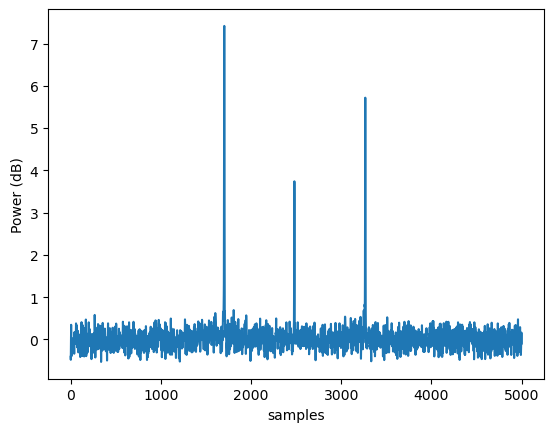

In [12]:
#incoherent sum
plt.plot(signal_dB[133000:138000], label='Ch 0')
plt.xlabel('samples')
plt.ylabel('Power (dB)')
plt.show()

In [13]:
noise = np.median(power)
signal = power/noise
signal_dB = 20*np.log10(signal)

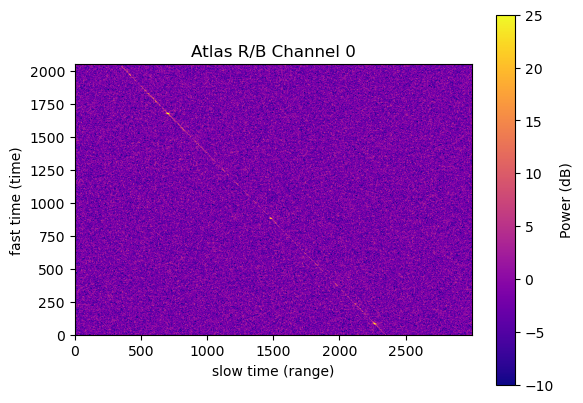

In [17]:
#rti
plt.imshow(signal_dB[:, 134000:137000], vmin=-10, vmax=25, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
cbar= plt.colorbar()
cbar.set_label('Power (dB)', rotation=90)
plt.xlabel('slow time (range)')
plt.ylabel('fast time (time)')
plt.show()

In [ ]:
r_i = []
sub_power = power[:, 134000:137000]
for i in range(sub_power.shape[0]):
    r_i.append(np.argmax(sub_power[i:i+1, :]))

time1 = np.arange(sub_power.shape[0])

In [227]:
data = power.T

r = np.zeros(data.shape[1], dtype=int)
r[0] = np.argmax(np.abs(data[:, 1]))

window = 10 

for i in range(1, data.shape[1]):
    prev = r[i-1]
    
    start = max(0, prev - window)
    end = min(data.shape[0], prev + window)
    segment = np.abs(data[start:end, i])

    #local maximum
    r[i] = start + np.argmax(segment)
   

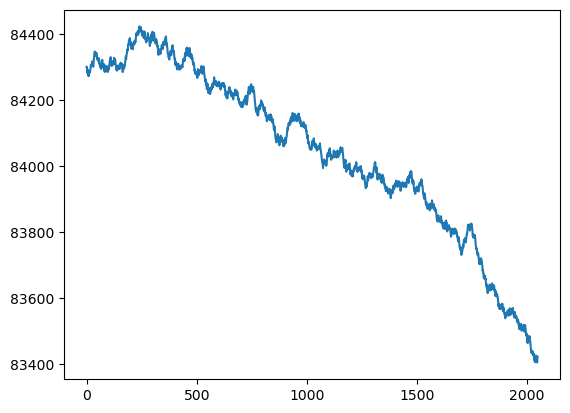

In [228]:
#plotting range per pulse 
plt.plot(time1, r)
plt.show()

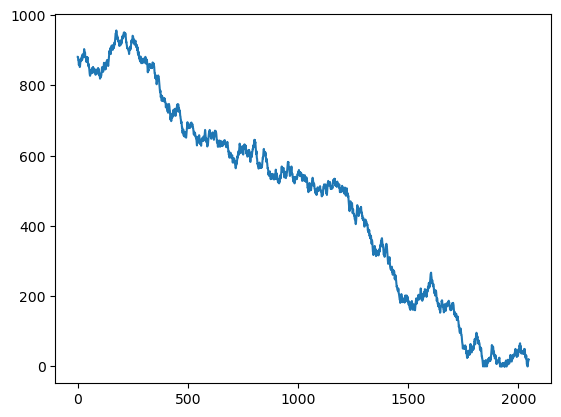

In [150]:
#plotting range per pulse 
plt.plot(time1, r)
plt.show()

In [231]:
coeffs = np.polyfit(time1, r, 2)   #2 is quadratic fit
r_fit = np.polyval(coeffs, time1)

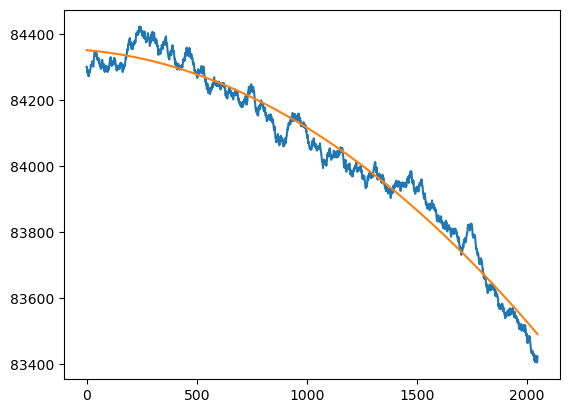

In [232]:
#plotting fit
plt.plot(time1, r)
plt.plot(time1, r_fit)
plt.show()

In [233]:
r_ref = r_fit[len(r_fit)//2]
rmc_shift = r_fit-r_ref

In [234]:
#takes about 3 minutes
corrected4 = np.zeros_like(cdat_pc)
for i in range(2048):
    corrected4[i, :] = imshift(cdat_pc[i, :], -rmc_shift[i])

In [235]:
power_corrected4 = (np.abs(corrected4))**2
spec_corrected4 = np.sum(power_corrected4, axis=0)

distribution is 57


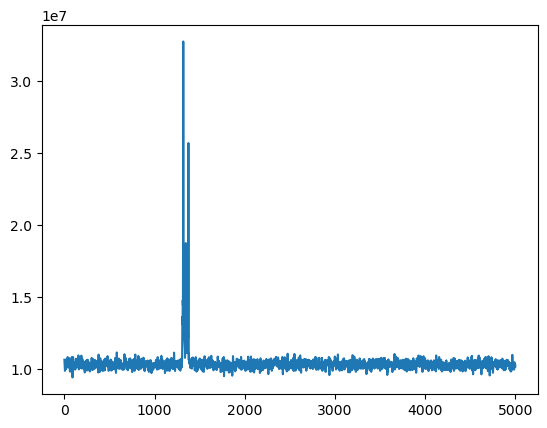

In [246]:
peaks, _ = find_peaks(spec_corrected, 1.5e7)
print('distribution is', peaks[-1]-peaks[0])
plt.plot(spec_corrected[134000:139000], label='Ch 0')
# plt.hlines((np.max(spec_corrected)-np.min(spec_corrected))/1.5, 0, 10000)
plt.show()

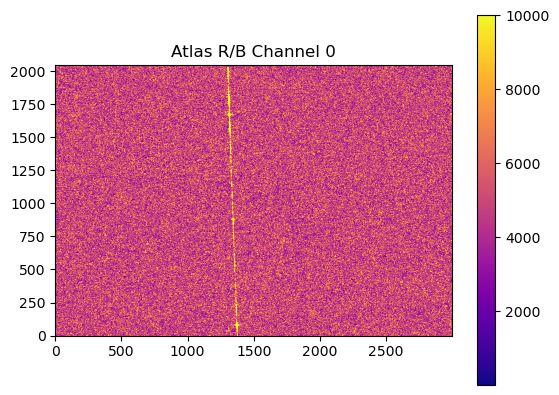

In [242]:
plt.imshow(power_corrected2[:, 134000:137000], vmax = 10000, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
plt.colorbar()
plt.show()

In [133]:
134810-134000

810

In [137]:
for i in range(3000):
    base_noise[:, i] = random.sample(range(1, 6000), 2048)

base_noise[:, 810] = [100000]*2048

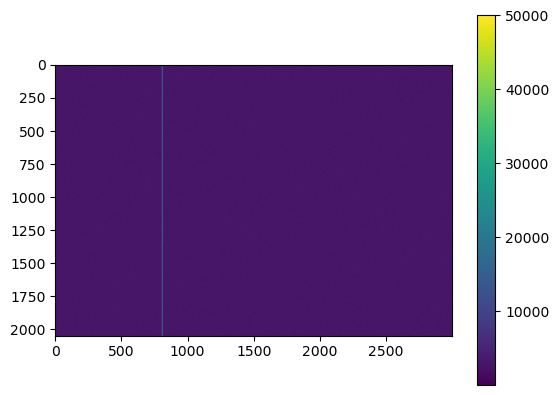

In [140]:
plt.imshow(base_noise, vmax=50000)
plt.colorbar()
plt.show()

In [106]:
power[12, 82]

8541.541550518192

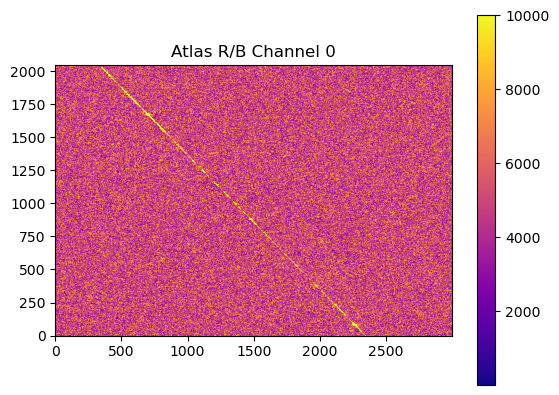

In [85]:
plt.imshow(power[:, 134000:137000], vmax = 10000, cmap = 'plasma', origin='lower')
plt.title('Atlas R/B Channel 0')
plt.colorbar()
plt.show()

In [ ]:
distribution_init = 842
for j in range(10):
    r_i = []
    sub_power = power[:, 134000:137000]
    data = sub_power.T

    r = np.zeros(data.shape[1], dtype=int)
    r[0] = np.argmax(np.abs(data[:, 1]))

    window = 10 

    for i in range(1, data.shape[1]):
        prev = r[i-1]
        
        start = max(0, prev - window)
        end = min(data.shape[0], prev + window)
        segment = np.abs(data[start:end, i])

        #local maximum
        r[i] = start + np.argmax(segment)
    
    coeffs = np.polyfit(time1, r, 2)   #quadratic fit
    r_fit = np.polyval(coeffs, time1)
    r_ref = r_fit[len(r_fit)//2]
    rmc_shift = r_fit-r_ref
    corrected = np.zeros_like(cdat_pc)
    for k in range(2048):
        corrected[k, :] = imshift(cdat_pc[k, :], -rmc_shift[k])

    power_corrected = (np.abs(corrected))**2
    spec_corrected = np.sum(power_corrected, axis=0)
    rough_threshold = (np.max(spec_corrected)-np.min(spec_corrected))/1.5
    peaks, _ = find_peaks(spec_corrected, rough_threshold)
    if len(peaks)<2:
        print('youve either done really well, or youve got the wrong threshold')

    else:
        distribution = peaks[-1]-peaks[0]
        print(distribution)
    
    if 
    
    

    


    
    

1245
1191
885
1396
1212
968
1337
989
1269
923


In [ ]:
height = 128 #coherent processing interval

reduced_length = height*points 

t1=np.linspace(0,pri,points,endpoint=False)

baseband_offset_term = np.exp(-2j*np.pi*f1*t1*tau_dot)

chirp_term= np.exp(1j*np.pi*alpha*t1**2*(1-tau_dot)**2) 

envelope_term = rect((t1)/(Tp*(1+tau_dot)))

In [ ]:
cpi_jump_samples = int(reduced_length)

# if doing successive cpis, this is the maximum number of strips you can get in your spectrogram
# now edited so it will be universal max (i think) - but for small increments this will be very large - don't run 10 million!
n_max_successive = int(np.floor((len(pola) - startoffset - 1- reduced_length)/reduced_length))
n_max_window = int(np.floor((len(pola)-startoffset-reduced_length)/cpi_jump_samples))

# if doing one sample difference, then n_max is very large 

number_of_strips_in_spectrogram = n_max_window

spectrogram = np.zeros((height, number_of_strips_in_spectrogram))
peak_range_history = []
peak_doppler_history = []

In [68]:
%%notify -m "Spectrogram generated..."
#looping over successive cpis to generate spectrogram
for n in range(number_of_strips_in_spectrogram):
    print("strip ", n, " of ", number_of_strips_in_spectrogram)
    # start_index = startoffset + (n*reduced_length)
    # end_index = startoffset + ((n+1)*reduced_length)
    start_index = cpi_jump_samples*n + startoffset
    end_index = cpi_jump_samples*(n+1)+ reduced_length + startoffset - cpi_jump_samples

    print('which covers samples ', start_index, " to ", end_index)
    pola_reduced = pola[start_index:end_index]
    dat = pola_reduced.reshape((height, points))
    dat = dat.astype(float)-1.5
    dat = dat - np.mean(dat, axis=1, keepdims=True)
    cdat = dat.astype(complex)
    cdat_pc = np.zeros_like(cdat)

    for i in range(height):
     start_sec=i*pri
     end_sec=(i+1)*pri
     t=np.linspace(start_sec,end_sec,points,endpoint=False)
     received_pulse=cdat[i]
     template = baseband_offset_term*chirp_term*envelope_term
     signal1_fft = np.fft.fft(received_pulse)
     signal2_fft = np.fft.fft(template)
     correlation2 = np.fft.ifft(signal1_fft * signal2_fft.conjugate()*phase_ramp)
     # correlation2_in_fd = np.fft.fft(correlation2)
     # timing_difference = estimate_delta_phase(correlation2, samp_rate)
     # digital_timing = np.exp(2j*np.pi*k*samp_rate*timing_difference) #peak not centred in discrete time interval correction
     # correlation3 = correlation2_in_fd * digital_timing
     # correlation3 = np.fft.ifft(correlation3)
     cdat_pc[i,:]=correlation2

     r_i = []
    power = (np.abs(cdat_pc))**2
    for i in range(power.shape[0]):
        r_i.append(np.argmax(power[i:i+1, :]))

    r = np.argmax(np.abs(power), axis=1)
    time1 = np.arange(power.shape[0]) 

    data = power.T

    r = np.zeros(data.shape[1], dtype=int)

    # initial position 
    r[0] = np.argmax(np.abs(data[:, 1]))

    window = 10  # range bins to search around

    for i in range(1, data.shape[1]):
        prev = r[i-1]
        
        # # define search window
        start = max(0, prev - window)
        end = min(data.shape[0], prev + window)

        segment = np.abs(data[start:end, i])

        # local argmax
        r[i] = start + np.argmax(segment)  

    coeffs = np.polyfit(time1, r, 2)   # quadratic fit
    r_fit = np.polyval(coeffs, time1)
    r_ref = r_fit[len(r_fit)//2]
    rmc_shift = r_fit - r_ref
    corrected = np.zeros_like(cdat_pc)

    corrected[:, i] = imshift(cdat_pc[:, i], -rmc_shift[i])

    print('Finished pulse compression')
    unshifted_range_doppler = np.fft.fft(cdat_pc, axis=0)
    range_doppler = np.fft.fftshift(unshifted_range_doppler, axes=0)
    rd_abs = np.abs(range_doppler ** 2)
    rd_abs_reduced = rd_abs[:, :]
    peaks = np.sum(rd_abs_reduced, axis = 0)
    peak = np.argmax(peaks)
    strip = rd_abs_reduced[:, peak:peak+1]
    print('Peak index: ', peak)
    # print(spectrogram[:, n:n+1])
    spectrogram[:, n:n+1] = strip
    peak_range_history.append(peak)
    # print(strip)
    # print(spectrogram[:, n:n+1])

strip  0  of  2
which covers samples  1600000000  to  2271940608


KeyboardInterrupt: 

<IPython.core.display.Javascript object>

In [ ]:
#only needed to save numpy array
np.save('./atlas_64overlap.npy', spectrogram)
#only needed if loading in previously saved spectrogram array
spectrogram = np.load('atlas_64overlap.npy')

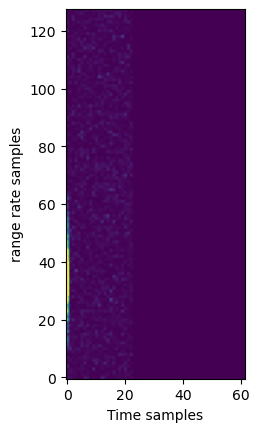

In [19]:
plt.imshow(spectrogram[:, :], vmax=3e7, origin='lower')#, extent = [time_labels[0], time_labels[-1], 0, 19], aspect='auto')
plt.xlabel('Time samples')
plt.ylabel ('range rate samples')
# plt.vlines((80, 92), 0, 39, 'r')
# plt.colorbar()
plt.show()